In [1]:
import os
import sys
import time
import copy

import json

In [39]:
class CharLevelTokenizer:
    """
    Tokenize text data at the level of the character.
    
    Args:
        chars: The list of unique characters.
    """
    def __init__(self, chars):

        self.unk_token = "[UNK]"
        self.unk_token_id = 0
        self.eos_token = "<eos>"

        self.vocab = {
            0: self.unk_token,
            1: self.eos_token
        }
        for i,ch in enumerate(sorted(chars)):
            self.vocab[i+2] = ch
        self.vocab_size = 2+len(chars)

        self.inv_vocab = {t:i for i,t in self.vocab.items()}

    def encode(self, text, end=False):
        if end:
            text = list(text) + [self.eos_token]
        return [self.inv_vocab.get(t, self.unk_token_id) for t in text]

    def decode(self, ids):
        return ''.join([self.vocab.get(i, self.unk_token) for i in ids])

    def save(self, path):
        with open(path, "w") as f:
            json.dump(self.vocab, f)

    @classmethod
    def load(cls, path):
        with open(path, "r") as f:
            vocab = json.load(f)
        tokenizer = cls.__new__(cls)  # create instance without calling __init__
        tokenizer.vocab = {int(i): t for i, t in vocab.items()}
        tokenizer.inv_vocab = {t: int(i) for i, t in vocab.items()}
        tokenizer.unk_token = "[UNK]"
        tokenizer.unk_token_id = tokenizer.inv_vocab["[UNK]"]
        tokenizer.eos_token = "<eos>"
        return tokenizer

TRAIN SPLIT

In [3]:
txt_file_path = "tinystories/TinyStoriesV2-GPT4-train.txt"

# Read the entire file
with open(txt_file_path, "r", encoding="utf-8") as f:
    data = f.read()
print(len(data))

# Split into individual stories
stories = data.split("<|endoftext|>")

# Filter out empty entries
stories = [story.strip() for story in stories if story.strip()]

print(f"Loaded {len(stories)} stories.")
print("First story:\n", stories[0])

2226845523
Loaded 2717495 stories.
First story:
 Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course you can. You can take it home and show all your friends how amazing it is!”
So Ben took the vase home and he was so proud of it! He called his friends over and showed them the amazing vase. All his friends thought the vase was beautiful and couldn't believe how lucky Ben was. 
And that's how Ben found an amazing vase in the store!


In [4]:
vocabulary = ''

for i, story in enumerate(stories):
        vocabulary = sorted(list(set(story+ ''.join(vocabulary))))
        if (i%1000)==0:
            print(f'{i} of {len(stories)}, vocab_size = {len(vocabulary)}')

0 of 2717495, vocab_size = 43
1000 of 2717495, vocab_size = 73
2000 of 2717495, vocab_size = 75
3000 of 2717495, vocab_size = 76
4000 of 2717495, vocab_size = 76
5000 of 2717495, vocab_size = 77
6000 of 2717495, vocab_size = 77
7000 of 2717495, vocab_size = 79
8000 of 2717495, vocab_size = 82
9000 of 2717495, vocab_size = 82
10000 of 2717495, vocab_size = 82
11000 of 2717495, vocab_size = 82
12000 of 2717495, vocab_size = 83
13000 of 2717495, vocab_size = 83
14000 of 2717495, vocab_size = 83
15000 of 2717495, vocab_size = 87
16000 of 2717495, vocab_size = 88
17000 of 2717495, vocab_size = 89
18000 of 2717495, vocab_size = 89
19000 of 2717495, vocab_size = 89
20000 of 2717495, vocab_size = 89
21000 of 2717495, vocab_size = 89
22000 of 2717495, vocab_size = 90
23000 of 2717495, vocab_size = 90
24000 of 2717495, vocab_size = 90
25000 of 2717495, vocab_size = 90
26000 of 2717495, vocab_size = 90
27000 of 2717495, vocab_size = 90
28000 of 2717495, vocab_size = 90
29000 of 2717495, vocab_siz

VALIDATION SPLIT

In [14]:
txt_file_path = "tinystories/TinyStoriesV2-GPT4-valid.txt"

# Read the entire file
with open(txt_file_path, "r", encoding="utf-8") as f:
    data_valid = f.read()
print(len(data_valid))

# Split into individual stories
stories_valid = data_valid.split("<|endoftext|>")

# Filter out empty entries
stories_valid = [story.strip() for story in stories_valid if story.strip()]

print(f"Loaded {len(stories_valid)} stories.")
print("First story:\n", stories_valid[0])

22493131
Loaded 27629 stories.
First story:
 Once upon a time, in a warm and sunny place, there was a big pit. A little boy named Tom liked to play near the pit. One day, Tom lost his red ball. He was very sad.
Tom asked his friend, Sam, to help him search for the ball. They looked high and low, but they could not find the ball. Tom said, "I think my ball fell into the pit."
Sam and Tom went close to the pit. They were scared, but they wanted to find the red ball. They looked into the pit, but it was too dark to see. Tom said, "We must go in and search for my ball."
They went into the pit to search. It was dark and scary. They could not find the ball. They tried to get out, but the pit was too deep. Tom and Sam were stuck in the pit. They called for help, but no one could hear them. They were sad and scared, and they never got out of the pit.


In [15]:
for i, story in enumerate(stories_valid):
        vocabulary = sorted(list(set(story+ ''.join(vocabulary))))
        if (i%1000)==0:
            print(f'{i} of {len(stories_valid)}, vocab_size = {len(vocabulary)}')

0 of 27629, vocab_size = 227
1000 of 27629, vocab_size = 227
2000 of 27629, vocab_size = 227
3000 of 27629, vocab_size = 227
4000 of 27629, vocab_size = 227
5000 of 27629, vocab_size = 227
6000 of 27629, vocab_size = 227
7000 of 27629, vocab_size = 229
8000 of 27629, vocab_size = 229
9000 of 27629, vocab_size = 229
10000 of 27629, vocab_size = 229
11000 of 27629, vocab_size = 229
12000 of 27629, vocab_size = 229
13000 of 27629, vocab_size = 229
14000 of 27629, vocab_size = 229
15000 of 27629, vocab_size = 229
16000 of 27629, vocab_size = 229
17000 of 27629, vocab_size = 229
18000 of 27629, vocab_size = 229
19000 of 27629, vocab_size = 229
20000 of 27629, vocab_size = 229
21000 of 27629, vocab_size = 229
22000 of 27629, vocab_size = 229
23000 of 27629, vocab_size = 229
24000 of 27629, vocab_size = 229
25000 of 27629, vocab_size = 229
26000 of 27629, vocab_size = 229
27000 of 27629, vocab_size = 229


BUILD CHARACTER-LEVEL TOKENIZER

In [ ]:
unique_chars = sorted(vocabulary)
print(unique_chars)
print(len(unique_chars))

tokenizer = CharLevelTokenizer(unique_chars)

print(tokenizer.vocab)

print(tokenizer.vocab_size)

{0: '[UNK]', 1: '<eos>', 2: '\t', 3: '\n', 4: ' ', 5: '!', 6: '"', 7: '#', 8: '$', 9: '%', 10: '&', 11: "'", 12: '(', 13: ')', 14: '*', 15: '+', 16: ',', 17: '-', 18: '.', 19: '/', 20: '0', 21: '1', 22: '2', 23: '3', 24: '4', 25: '5', 26: '6', 27: '7', 28: '8', 29: '9', 30: ':', 31: ';', 32: '<', 33: '=', 34: '>', 35: '?', 36: '@', 37: 'A', 38: 'B', 39: 'C', 40: 'D', 41: 'E', 42: 'F', 43: 'G', 44: 'H', 45: 'I', 46: 'J', 47: 'K', 48: 'L', 49: 'M', 50: 'N', 51: 'O', 52: 'P', 53: 'Q', 54: 'R', 55: 'S', 56: 'T', 57: 'U', 58: 'V', 59: 'W', 60: 'X', 61: 'Y', 62: 'Z', 63: '[', 64: '\\', 65: ']', 66: '_', 67: '`', 68: 'a', 69: 'b', 70: 'c', 71: 'd', 72: 'e', 73: 'f', 74: 'g', 75: 'h', 76: 'i', 77: 'j', 78: 'k', 79: 'l', 80: 'm', 81: 'n', 82: 'o', 83: 'p', 84: 'q', 85: 'r', 86: 's', 87: 't', 88: 'u', 89: 'v', 90: 'w', 91: 'x', 92: 'y', 93: 'z', 94: '{', 95: '|', 96: '}', 97: '~', 98: '\x92', 99: '\x93', 100: '\x94', 101: '\xa0', 102: '¡', 103: '¢', 104: '£', 105: '§', 106: '«', 107: '\xad', 108

In [31]:
# example

print(stories[0])
token_ids = tokenizer.encode(stories[0], end=True)
print(token_ids)

Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course you can. You can take it home and show all your friends how amazing it is!”
So Ben took the vase home and he was so proud of it! He called his friends over and showed them the amazing vase. All his friends thought the vase was beautiful and couldn't believe how lucky Ben was. 
And that's how Ben found an amazing vase in the store!
[51, 81, 70, 72, 4, 88, 83, 82, 81, 4, 68, 4, 87, 76, 80, 72, 4, 87, 75, 72, 85, 72, 4, 90, 68, 86, 4, 68, 4, 79, 76, 87, 87, 79, 72, 4, 69, 82, 92, 4, 81, 68, 80, 72, 71, 4, 38, 72, 81, 18, 4, 38, 72, 81, 4, 79, 82, 89, 72, 71, 4, 87, 82, 4, 72, 91, 83, 79, 82, 85, 72

In [32]:
print(tokenizer.vocab[51], tokenizer.vocab[81], tokenizer.vocab[70], tokenizer.vocab[72], tokenizer.vocab[4], tokenizer.vocab[88])

O n c e   u


In [33]:
text = tokenizer.decode(token_ids)
print(text)

Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course you can. You can take it home and show all your friends how amazing it is!”
So Ben took the vase home and he was so proud of it! He called his friends over and showed them the amazing vase. All his friends thought the vase was beautiful and couldn't believe how lucky Ben was. 
And that's how Ben found an amazing vase in the store!<eos>


In [ ]:
# save vocabulary as .json
tokenizer.save("tinystories/tinystories.char.tokenizer.json")

In [ ]:
# load from vocabulary saved as .json
tokenizer2 = CharLevelTokenizer.load("tinystories/tinystories.char.tokenizer.json")
token_ids_2 = tokenizer2.encode(stories[0], end=True)
print(token_ids_2)
print(token_ids)

[51, 81, 70, 72, 4, 88, 83, 82, 81, 4, 68, 4, 87, 76, 80, 72, 4, 87, 75, 72, 85, 72, 4, 90, 68, 86, 4, 68, 4, 79, 76, 87, 87, 79, 72, 4, 69, 82, 92, 4, 81, 68, 80, 72, 71, 4, 38, 72, 81, 18, 4, 38, 72, 81, 4, 79, 82, 89, 72, 71, 4, 87, 82, 4, 72, 91, 83, 79, 82, 85, 72, 4, 87, 75, 72, 4, 90, 82, 85, 79, 71, 4, 68, 85, 82, 88, 81, 71, 4, 75, 76, 80, 18, 4, 44, 72, 4, 86, 68, 90, 4, 80, 68, 81, 92, 4, 68, 80, 68, 93, 76, 81, 74, 4, 87, 75, 76, 81, 74, 86, 16, 4, 79, 76, 78, 72, 4, 69, 72, 68, 88, 87, 76, 73, 88, 79, 4, 89, 68, 86, 72, 86, 4, 87, 75, 68, 87, 4, 90, 72, 85, 72, 4, 82, 81, 4, 71, 76, 86, 83, 79, 68, 92, 4, 76, 81, 4, 68, 4, 86, 87, 82, 85, 72, 18, 4, 51, 81, 72, 4, 71, 68, 92, 16, 4, 38, 72, 81, 4, 90, 68, 86, 4, 90, 68, 79, 78, 76, 81, 74, 4, 87, 75, 85, 82, 88, 74, 75, 4, 87, 75, 72, 4, 86, 87, 82, 85, 72, 4, 90, 75, 72, 81, 4, 75, 72, 4, 70, 68, 80, 72, 4, 68, 70, 85, 82, 86, 86, 4, 68, 4, 89, 72, 85, 92, 4, 86, 83, 72, 70, 76, 68, 79, 4, 89, 68, 86, 72, 18, 4, 59, 75, 7

## TOKENIZE TRAIN SPLIT

In [46]:
lengths = []
tokenised = []
for story in stories:
    output = tokenizer.encode(story, end=True)
    tokenised += output
    lengths.append(len(output))

Number of tokens:  2187705082
min/max story length:  4 5496
average story length:  805.0447496683527


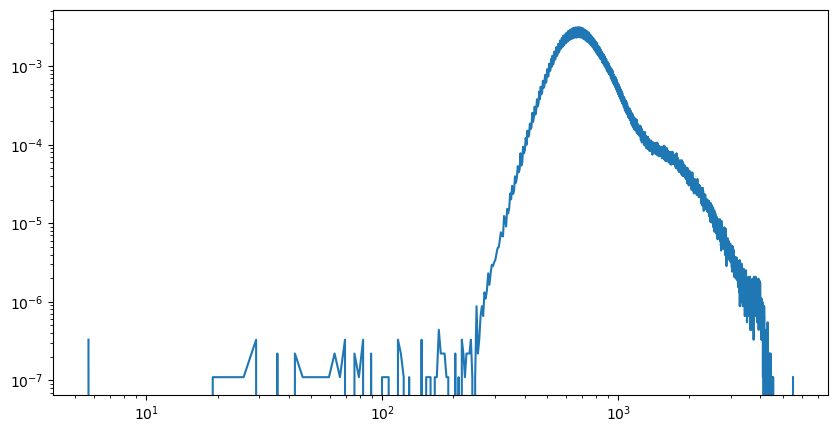

In [47]:
import numpy as np
import matplotlib.pyplot as plt

print('Number of tokens: ', len(tokenised))
print('min/max story length: ', min(lengths), max(lengths))
print('average story length: ', sum(lengths)/len(lengths))

fig, ax = plt.subplots( 1, 1, figsize=(10,5))

hist, bins = np.histogram(np.array(lengths), bins='fd', density=True)
centres = []
for k in range(len(hist)):
    point = (bins[k+1] + bins[k]) * 0.5
    centres.append(point)
ax.plot( centres, hist, 'C0')

ax.set_xscale('log')
ax.set_yscale('log')

In [ ]:
np.save("tinystories/tinystories.char.train.npy", np.array(tokenised, dtype=np.int32))

In [ ]:
loaded = np.load("tinystories/tinystories.char.train.npy")
print(len(loaded))

loaded_text = tokenizer.decode(loaded[:1024])
print(loaded_text)

2187705082


## TOKENISE VALIDATION SPLIT

In [124]:
lengths = []
tokenised = []
for story in stories_valid:
    output = tokenizer.encode(story, end=True)
    tokenised += output
    lengths.append(len(output))

Number of tokens:  22095292
min/max story length:  258 4165
average story length:  799.7137790003258


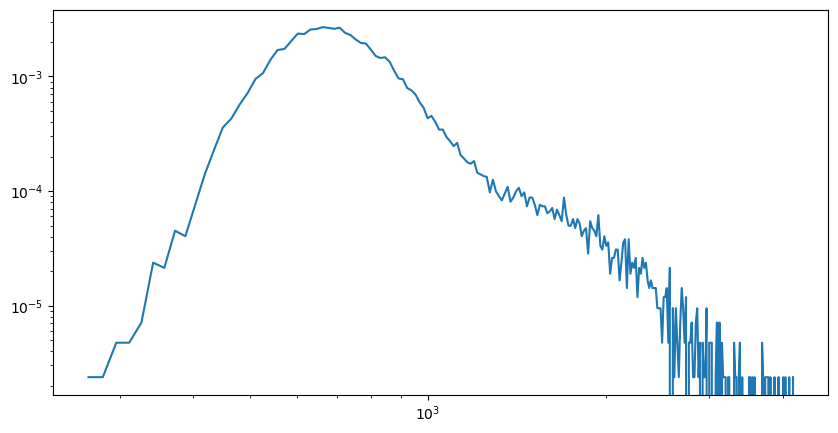

In [125]:
print('Number of tokens: ', len(tokenised))
print('min/max story length: ', min(lengths), max(lengths))
print('average story length: ', sum(lengths)/len(lengths))

fig, ax = plt.subplots( 1, 1, figsize=(10,5))

hist, bins = np.histogram(np.array(lengths), bins='fd', density=True)
centres = []
for k in range(len(hist)):
    point = (bins[k+1] + bins[k]) * 0.5
    centres.append(point)
ax.plot( centres, hist, 'C0')

ax.set_xscale('log')
ax.set_yscale('log')

In [126]:
np.save("tinystories/tinystories.char.valid.npy", np.array(tokenised, dtype=np.int32))